# Hyperparameter tuning, ROC-AUC and K-Means

**Week 1 · Traditional Machine Learning**

| Part | Topic |
|---|---|
| **1** | Hyperparameter tuning: `GridSearchCV` vs `RandomizedSearchCV` |
| **2** | ROC curve and AUC, explained step by step |
| **3** | Unsupervised learning: K-Means step by step, choosing K, a real example |

All datasets come with scikit-learn, so there's nothing to download.

> **Setup:** `uv add pandas numpy matplotlib scikit-learn scipy jupyter`

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.precision", 3)

---
# Part 1: Hyperparameter tuning

- **Parameters** are *learned* from the data during training (the split points in a tree, the weights in logistic regression).
- **Hyperparameters** are settings *you choose* before training (`max_depth`, `n_estimators`, `C`…).

Tuning means finding the hyperparameter values that give the best performance on **unseen** data. We measure that with **cross-validation** on the training set, and keep the test set for one final check.

## The data: breast cancer diagnosis

569 tumour samples, 30 numeric measurements each. In scikit-learn's version `1` means *benign*. We flip it so that **`1` = malignant**: the positive class is the one we're looking for.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer(as_frame=True)
X = data.data
y = (data.target == 0).astype(int).rename("malignant")   # 1 = malignant (positive class)

print("Shape:", X.shape)
print(y.value_counts().rename({0: "benign (0)", 1: "malignant (1)"}))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

Shape: (569, 30)
malignant
benign (0)       357
malignant (1)    212
Name: count, dtype: int64


## Baseline: default hyperparameters

Always start with a baseline, so you know whether tuning actually helped.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = RandomForestClassifier(random_state=RANDOM_STATE)
baseline_scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="f1")
print(f"Baseline Random Forest, cross-validated F1: {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}")

Baseline Random Forest, cross-validated F1: 0.939 ± 0.028


## Grid search: try every combination

You list candidate values for each hyperparameter; `GridSearchCV` tries **every combination**, scores each one with cross-validation, and keeps the best.

```
max_depth         ×  min_samples_leaf  ×  n_estimators   =  combinations
[3, 5, 10, None]     [1, 2, 5, 10]        [50, 200]          4 × 4 × 2 = 32
```

With 5-fold cross-validation that's **32 × 5 = 160 model fits**. The cost multiplies with every hyperparameter you add.

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "n_estimators": [50, 200],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",        # choose the metric that matters for the problem (the default is accuracy)
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

start = time.perf_counter()
grid.fit(X_train, y_train)
grid_time = time.perf_counter() - start

print(f"Combinations tried: {len(grid.cv_results_['params'])}  ({len(grid.cv_results_['params']) * cv.get_n_splits()} fits)")
print(f"Time: {grid_time:.1f}s")
print("Best hyperparameters:", grid.best_params_)
print(f"Best cross-validated F1: {grid.best_score_:.3f}")

Combinations tried: 32  (160 fits)
Time: 5.2s
Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best cross-validated F1: 0.945


### Looking inside the search

`cv_results_` records every combination. Sorting it shows which settings worked, and the train-vs-validation columns show whether any of them overfit.

In [5]:
results = pd.DataFrame(grid.cv_results_)
cols = ["param_max_depth", "param_min_samples_leaf", "param_n_estimators",
        "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
results[cols].sort_values("rank_test_score").head(8)

,param_max_depth,param_min_samples_leaf,param_n_estimators,mean_train_score,mean_test_score,std_test_score,rank_test_score
17,10,1,200,1.000,0.945,0.030,1
25,None,1,200,1.000,0.945,0.030,1
24,None,1,50,1.000,0.945,0.032,3
16,10,1,50,1.000,0.945,0.032,3
8,5,1,50,0.990,0.942,0.029,5
12,5,5,50,0.968,0.942,0.029,5
11,5,2,200,0.988,0.942,0.024,7
0,3,1,50,0.974,0.940,0.026,8


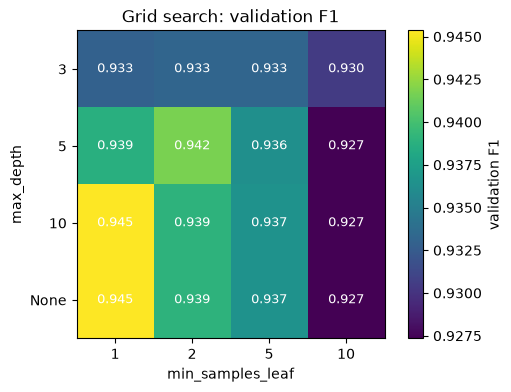

In [6]:
# Heatmap: validation F1 for max_depth × min_samples_leaf (n_estimators = 200)
subset = results[results["param_n_estimators"] == 200]
heat = subset.pivot_table(index="param_max_depth", columns="param_min_samples_leaf",
                          values="mean_test_score", dropna=False)
heat.index = heat.index.map(lambda d: "None" if pd.isna(d) else int(d))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heat.values, cmap="viridis")
ax.set_xticks(range(len(heat.columns)), heat.columns)
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=9)
fig.colorbar(im, label="validation F1")
ax.set_title("Grid search: validation F1")
plt.show()

## Random search: try N random combinations

Instead of every combination, `RandomizedSearchCV` samples **`n_iter` random combinations** from ranges or distributions.

**Why it often wins:** usually only one or two hyperparameters really matter. A grid wastes most of its budget repeating the same few values of the important ones; random search tries a *different* value of every hyperparameter on every attempt, so it explores the important ones far more thoroughly for the same cost.

```
Grid (9 tries)          Random (9 tries)
x  x  x                 x      x
x  x  x                    x       x  x
x  x  x                  x    x      x
-> only 3 distinct       -> 9 distinct values
   values of each           of each
```

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    "max_depth": [3, 5, 8, 10, 15, None],
    "min_samples_leaf": randint(1, 20),       # any whole number from 1 to 19
    "n_estimators": randint(50, 400),
    "max_features": ["sqrt", "log2", 0.5],
}

rand = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=20,           # only 20 combinations, from a much bigger search space
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

start = time.perf_counter()
rand.fit(X_train, y_train)
rand_time = time.perf_counter() - start

print(f"Combinations tried: {rand.n_iter}  ({rand.n_iter * cv.get_n_splits()} fits)")
print(f"Time: {rand_time:.1f}s")
print("Best hyperparameters:", rand.best_params_)
print(f"Best cross-validated F1: {rand.best_score_:.3f}")

Combinations tried: 20  (100 fits)
Time: 2.3s
Best hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 363}
Best cross-validated F1: 0.952


## Comparing them, and the final test

After the search, `best_estimator_` is already **refitted on the whole training set** with the best hyperparameters. Now, and only now, we use the test set.

In [8]:
from sklearn.metrics import f1_score

baseline.fit(X_train, y_train)

summary = pd.DataFrame([
    {"method": "Baseline (defaults)", "combinations": 1, "cv_f1": baseline_scores.mean(),
     "test_f1": f1_score(y_test, baseline.predict(X_test)), "seconds": None},
    {"method": "GridSearchCV", "combinations": len(grid.cv_results_["params"]), "cv_f1": grid.best_score_,
     "test_f1": f1_score(y_test, grid.best_estimator_.predict(X_test)), "seconds": grid_time},
    {"method": "RandomizedSearchCV", "combinations": rand.n_iter, "cv_f1": rand.best_score_,
     "test_f1": f1_score(y_test, rand.best_estimator_.predict(X_test)), "seconds": rand_time},
])
summary

,method,combinations,cv_f1,test_f1,seconds
0,Baseline (defaults),1,0.939,0.95,NaN
1,GridSearchCV,32,0.945,0.94,5.239
2,RandomizedSearchCV,20,0.952,0.94,2.342


**Takeaways**
- Tuning raised the **cross-validated** F1 a little, but the **test** F1 didn't improve. That's normal here: Random Forest's defaults are already good, and the test set has only 142 patients, so a 0.01 difference in F1 is about **one patient**. Weaker defaults (SVM's `C`/`gamma`, boosting's `learning_rate`) gain much more from tuning.
- **Random search** reaches a similar score with fewer fits, while exploring a much larger space.
- Differences smaller than the `std_test_score` column (about 0.03 here) are **noise**, not real improvements. Don't over-celebrate a tuned score.

| | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| Tries | Every combination | `n_iter` random combinations |
| Cost | Multiplies with each hyperparameter | You fix it with `n_iter` |
| Best for | 2–3 hyperparameters with a few known values | Many hyperparameters, wide or continuous ranges |
| Typical use | Fine-tuning around a known good region | First exploration; boosting models |

> **A common workflow:** random search first to find the promising region, then a small grid search around it.

> ⚠️ **Never tune on the test set.** The search uses cross-validation on the training data only. If you peek at the test set while tuning, it stops being an honest estimate.

### Tuning a pipeline

When preprocessing is needed (scaling for SVM, for example), tune the **whole pipeline** so scaling is refitted inside each fold. Use `step__parameter` names:

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from scipy.stats import loguniform

svm_pipe = Pipeline([("scale", StandardScaler()), ("svm", SVC())])

svm_search = RandomizedSearchCV(
    svm_pipe,
    param_distributions={
        "svm__C": loguniform(0.01, 100),        # log scale: equally likely to try 0.1, 1, 10…
        "svm__gamma": loguniform(0.0001, 1),
        "svm__kernel": ["rbf", "linear"],
    },
    n_iter=30, scoring="f1", cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
).fit(X_train, y_train)

print("Best:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in svm_search.best_params_.items()})
print(f"CV F1: {svm_search.best_score_:.3f} · test F1: {f1_score(y_test, svm_search.predict(X_test)):.3f}")

Best: {'svm__C': np.float64(85.6887), 'svm__gamma': np.float64(0.0074), 'svm__kernel': 'rbf'}
CV F1: 0.965 · test F1: 0.941


**Use `loguniform` for hyperparameters that span orders of magnitude** (`C`, `gamma`, `learning_rate`, `alpha`). A plain uniform range from 0.01 to 100 would spend almost all its tries above 1.

---
# Part 2: ROC curve and AUC in simple terms

## The idea in one sentence

A classifier gives every case a **score** (a probability). A good model gives **positives higher scores than negatives**. **AUC measures how often that's true.**

## Step 1: a tiny example

10 patients: 4 really have the disease (positive), 6 don't. The model has given each one a score:

In [10]:
patients = pd.DataFrame({
    "patient": list("ABCDEFGHIJ"),
    "score":   [0.95, 0.85, 0.80, 0.70, 0.60, 0.55, 0.45, 0.30, 0.20, 0.10],
    "actual":  [1,    1,    0,    1,    0,    1,    0,    0,    0,    0],
})
patients

,patient,score,actual
0,A,0.95,1
1,B,0.85,1
2,C,0.80,0
3,D,0.70,1
4,E,0.60,0
5,F,0.55,1
6,G,0.45,0
7,H,0.30,0
8,I,0.20,0
9,J,0.10,0


Sorted by score, the positives are *mostly* at the top. Not perfectly: patient C (a negative) scored higher than patients D and F (positives).

## Step 2: every threshold gives one point

Pick a threshold: everyone **at or above** it is predicted positive. Then count:
- **True positive rate (TPR) = recall** = positives caught ÷ all positives (we want this high)
- **False positive rate (FPR)** = negatives wrongly flagged ÷ all negatives (we want this low)

Slide the threshold from very high (flag nobody) to very low (flag everybody):

In [11]:
P = patients["actual"].sum()          # 4 positives
N = len(patients) - P                 # 6 negatives

rows = []
for threshold in [1.0] + list(patients["score"]):
    flagged = patients["score"] >= threshold
    tp = (flagged & (patients["actual"] == 1)).sum()
    fp = (flagged & (patients["actual"] == 0)).sum()
    rows.append({"threshold": threshold, "flagged": int(flagged.sum()), "TP": tp, "FP": fp,
                 "TPR (recall)": tp / P, "FPR": fp / N})
roc_table = pd.DataFrame(rows)
roc_table

,threshold,flagged,TP,FP,TPR (recall),FPR
0,1.00,0,0,0,0.00,0.000
1,0.95,1,1,0,0.25,0.000
2,0.85,2,2,0,0.50,0.000
3,0.80,3,2,1,0.50,0.167
4,0.70,4,3,1,0.75,0.167
5,0.60,5,3,2,0.75,0.333
6,0.55,6,4,2,1.00,0.333
7,0.45,7,4,3,1.00,0.500
8,0.30,8,4,4,1.00,0.667
9,0.20,9,4,5,1.00,0.833


## Step 3: plot the points, and that's the ROC curve

**ROC** = Receiver Operating Characteristic (the name comes from WWII radar). Each row of the table becomes one point:

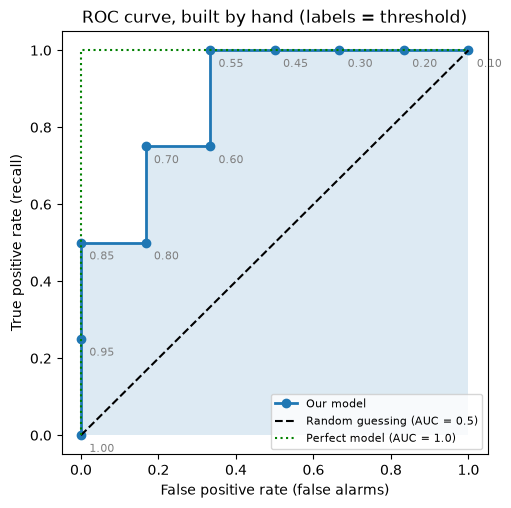

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(roc_table["FPR"], roc_table["TPR (recall)"], marker="o", linewidth=2, label="Our model")
for _, r in roc_table.iterrows():
    ax.annotate(f"{r['threshold']:.2f}", (r["FPR"], r["TPR (recall)"]), textcoords="offset points",
                xytext=(6, -12), fontsize=8, color="gray")
ax.plot([0, 1], [0, 1], "k--", label="Random guessing (AUC = 0.5)")
ax.plot([0, 0, 1], [0, 1, 1], ":", color="green", label="Perfect model (AUC = 1.0)")
ax.fill_between(roc_table["FPR"], roc_table["TPR (recall)"], step=None, alpha=0.15)
ax.set_xlabel("False positive rate (false alarms)")
ax.set_ylabel("True positive rate (recall)")
ax.set_title("ROC curve, built by hand (labels = threshold)")
ax.legend(loc="lower right", fontsize=8)
plt.show()

**How to read it**
- **Bottom-left (0, 0):** threshold so high that nobody is flagged. No false alarms, but nothing is caught.
- **Top-right (1, 1):** threshold so low that everyone is flagged. Everything is caught, along with every false alarm.
- **A good model shoots up first** (catches positives before raising false alarms), hugging the **top-left corner**.
- **The diagonal** is a coin flip: catching more positives costs false alarms at the same rate.

## Step 4: AUC = the area under that curve

In [13]:
from sklearn.metrics import roc_auc_score

area = np.trapezoid(roc_table["TPR (recall)"], roc_table["FPR"])
print(f"Area under our hand-made curve: {area:.3f}")
print(f"scikit-learn's roc_auc_score:   {roc_auc_score(patients['actual'], patients['score']):.3f}")

Area under our hand-made curve: 0.875
scikit-learn's roc_auc_score:   0.875


## Step 5: what the AUC number actually means

> **AUC = the probability that a randomly chosen positive gets a higher score than a randomly chosen negative.**

Let's check by brute force: compare **every positive with every negative**, 4 × 6 = 24 pairs, and count how often the positive wins.

In [14]:
pos_scores = patients.loc[patients["actual"] == 1, "score"]
neg_scores = patients.loc[patients["actual"] == 0, "score"]

wins = sum(p > n for p in pos_scores for n in neg_scores)
pairs = len(pos_scores) * len(neg_scores)
print(f"Positive ranked above negative in {wins} of {pairs} pairs = {wins / pairs:.3f}")

Positive ranked above negative in 21 of 24 pairs = 0.875


Exactly the same number. So an AUC of 0.875 means: *"pick one sick and one healthy patient at random; 87.5% of the time the model gives the sick one a higher score."*

| AUC | Meaning |
|---|---|
| **1.0** | Perfect ranking: every positive scores above every negative |
| **0.9–1.0** | Excellent |
| **0.8–0.9** | Good |
| **0.7–0.8** | Fair |
| **0.5** | No better than a coin flip |
| **< 0.5** | Worse than random: the model is backwards (flip its predictions) |

## Why use AUC instead of accuracy?

1. **It doesn't depend on a threshold.** Accuracy, precision and recall all change when you move the threshold; AUC judges the model's *ranking* across all thresholds at once.
2. **It isn't fooled by imbalance.** With 99% negatives, "always predict negative" scores 99% accuracy but an AUC of 0.5, which is exactly what it deserves.
3. **It's great for comparing models.** Pick the model with the best AUC, then choose the threshold for the business.

## Step 6: comparing real models

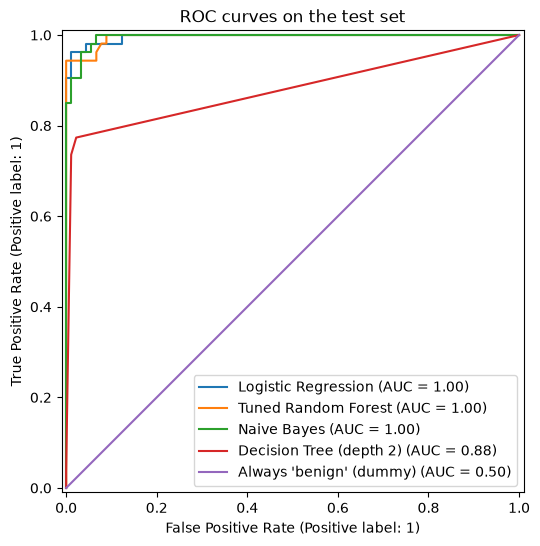

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import RocCurveDisplay

models = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]),
    "Tuned Random Forest": grid.best_estimator_,
    "Naive Bayes": GaussianNB(),
    "Decision Tree (depth 2)": DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
    "Always 'benign' (dummy)": DummyClassifier(strategy="most_frequent"),
}

fig, ax = plt.subplots(figsize=(6.5, 6))
for name, model in models.items():
    model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC curves on the test set")
plt.show()

- **Logistic regression** and the **tuned random forest** hug the top-left corner: AUC close to 1.
- The **depth-2 tree** only has a few distinct scores, so its curve is made of a few straight segments.
- The **dummy model** lies on the diagonal: AUC 0.5, no skill, even though its accuracy is about 63%.

> **One caution:** when positives are *very* rare (under about 5%), ROC can look optimistic. Also check the **precision-recall curve** / **average precision**. See `imbalanced_classification.ipynb`.

---
# Part 3: Unsupervised learning with K-Means

## Supervised vs unsupervised

| | Supervised | Unsupervised |
|---|---|---|
| Labels (`y`) | ✅ Known answers | ❌ No answers |
| Goal | Predict the label | **Find structure** in the data |
| Examples | Classification, regression | **Clustering**, dimensionality reduction |
| Business use | "Will this customer churn?" | "What types of customers do we have?" |

**Clustering** groups similar data points together. **K-Means** is the most popular clustering algorithm.

## The K-Means algorithm

1. **Choose K**, the number of clusters.
2. **Initialise:** place K centroids (cluster centres) at random points.
3. **Assign:** each point joins its **nearest** centroid.
4. **Update:** move each centroid to the **average (mean)** of its points. That's where the name comes from.
5. **Repeat** steps 3–4 until the centroids stop moving.

Let's code exactly that, by hand, and watch it work.

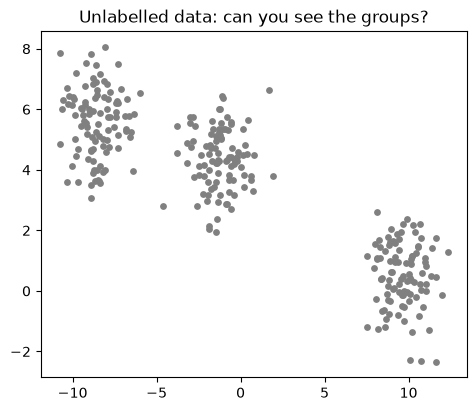

In [16]:
from sklearn.datasets import make_blobs

X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.1, random_state=7)

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=15, color="gray")
plt.title("Unlabelled data: can you see the groups?")
plt.show()

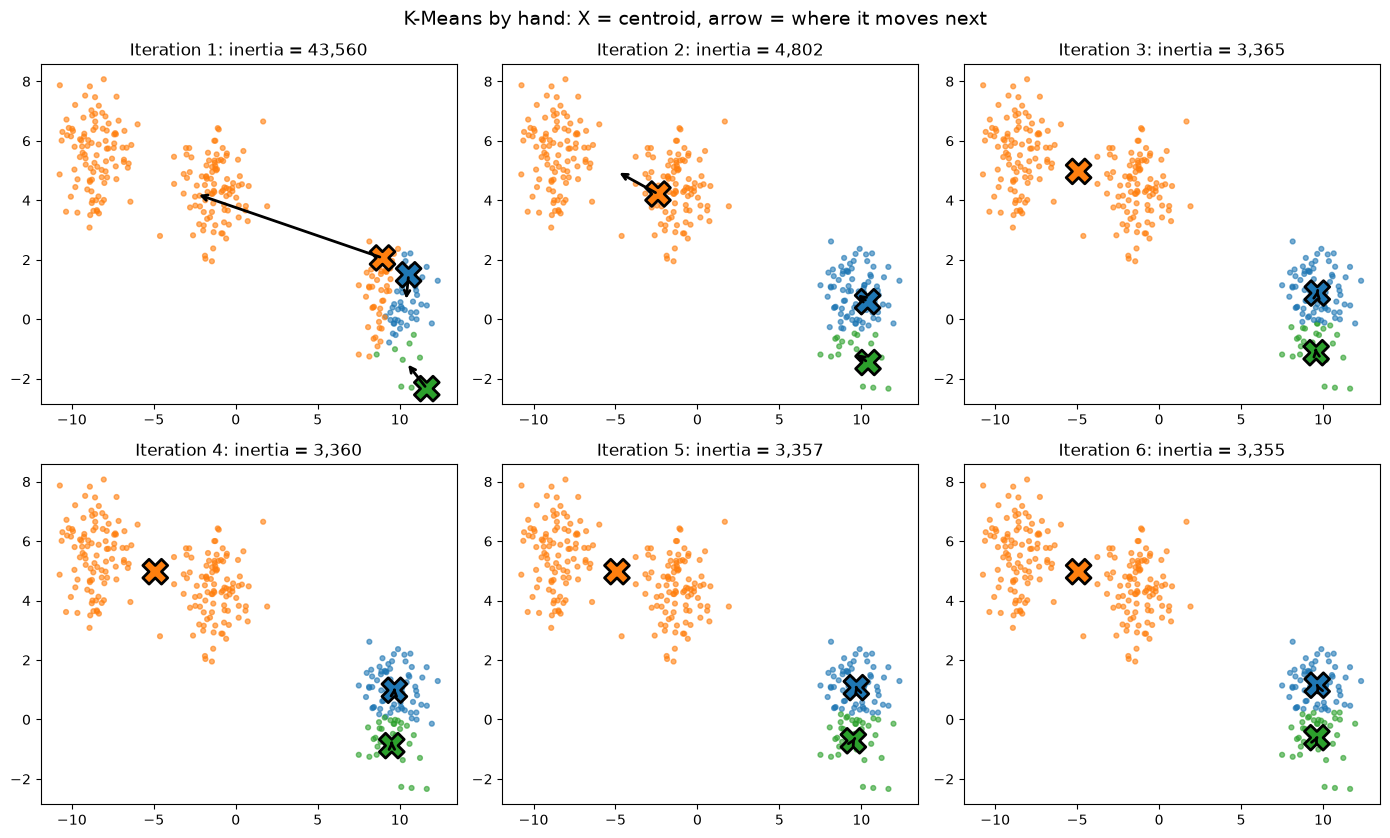

Converged after 11 iterations (centroids moved 0.0e+00 in the last step)


In [17]:
def assign(X, centroids):
    """Step 3: the index of the nearest centroid for every point."""
    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)   # every point to every centroid
    return distances.argmin(axis=1)


def update(X, labels, k):
    """Step 4: move each centroid to the mean of its points."""
    return np.array([X[labels == j].mean(axis=0) for j in range(k)])


K = 3
rng = np.random.default_rng(3)
centroids = X_blobs[rng.choice(len(X_blobs), K, replace=False)]   # step 2: K random points as starting centroids

colors = np.array(["tab:blue", "tab:orange", "tab:green"])
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))
history = []
for step, ax in enumerate(axes.flat):
    labels = assign(X_blobs, centroids)
    inertia = ((X_blobs - centroids[labels]) ** 2).sum()
    history.append(inertia)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=colors[labels], s=12, alpha=0.6)
    ax.scatter(centroids[:, 0], centroids[:, 1], c=colors, s=320, marker="X", edgecolor="black", linewidth=2)
    new_centroids = update(X_blobs, labels, K)
    for old, new in zip(centroids, new_centroids):
        ax.annotate("", xy=new, xytext=old, arrowprops=dict(arrowstyle="->", lw=2))
    ax.set_title(f"Iteration {step + 1}: inertia = {inertia:,.0f}")
    moved = np.linalg.norm(new_centroids - centroids)
    centroids = new_centroids
plt.suptitle("K-Means by hand: X = centroid, arrow = where it moves next", fontsize=14)
plt.tight_layout()
plt.show()

# Step 5: keep repeating until the centroids stop moving
iteration = len(history)
while moved > 1e-6:
    labels = assign(X_blobs, centroids)
    history.append(((X_blobs - centroids[labels]) ** 2).sum())
    new_centroids = update(X_blobs, labels, K)
    moved = np.linalg.norm(new_centroids - centroids)
    centroids = new_centroids
    iteration += 1
print(f"Converged after {iteration} iterations (centroids moved {moved:.1e} in the last step)")

**What you're seeing**
- **Iteration 1:** random starting centroids, so the groups are messy.
- Each iteration **assigns** points to the nearest X, then the arrow shows the X **moving** to the centre of its points.
- The moves get smaller each time; the loop after the plots keeps going until the centroids **stop moving**, at which point the algorithm has **converged**.

**Inertia** (within-cluster sum of squares, WCSS) is the total squared distance from each point to its centroid. Lower = tighter clusters. K-Means is guaranteed never to increase it from one iteration to the next:

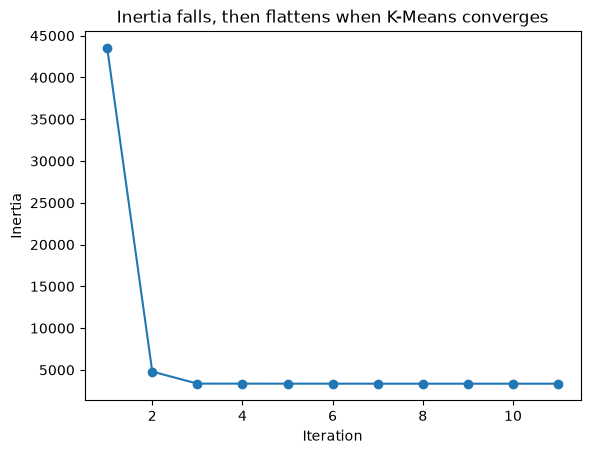

In [18]:
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("Inertia falls, then flattens when K-Means converges")
plt.show()

## The same thing with scikit-learn

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)

print("Cluster sizes:", np.bincount(kmeans.labels_))
print(f"Inertia: {kmeans.inertia_:,.0f}")
print("Centroids:\n", kmeans.cluster_centers_.round(2))

Cluster sizes: [100 100 100]
Inertia: 694
Centroids:
 [[ 9.64  0.52]
 [-8.56  5.57]
 [-1.26  4.38]]


**Two things scikit-learn adds:**
- **`k-means++` initialisation** (the default) spreads out the starting centroids instead of picking them purely at random, so it converges faster and more reliably.
- **`n_init=10`** runs the whole algorithm 10 times from different starting points and keeps the result with the lowest inertia. A bad random start can otherwise get stuck in a poor solution.

## Choosing K: the elbow method

In real data we don't know K. Try several values and plot inertia:

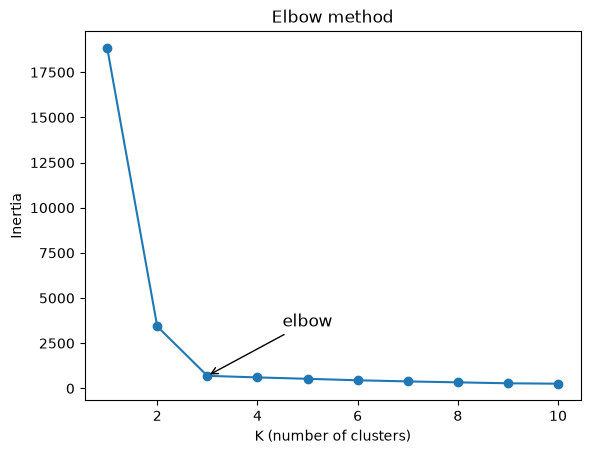

In [20]:
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blobs).inertia_ for k in ks]

plt.plot(ks, inertias, marker="o")
plt.annotate("elbow", xy=(3, inertias[2]), xytext=(4.5, inertias[1]),
             arrowprops=dict(arrowstyle="->"), fontsize=12)
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

Inertia **always** goes down as K grows (with K = number of points, it reaches 0), so we don't look for the minimum. We look for the **elbow**: the point after which adding clusters stops helping much. Here it's clearly **K = 3**.

## A second opinion: the silhouette score

For each point the silhouette compares *how close it is to its own cluster* with *how close it is to the nearest other cluster*:
- **+1:** well inside its cluster, far from the others
- **0:** on the border between two clusters
- **−1:** probably in the wrong cluster

Unlike inertia, the average silhouette **peaks** at a good K:

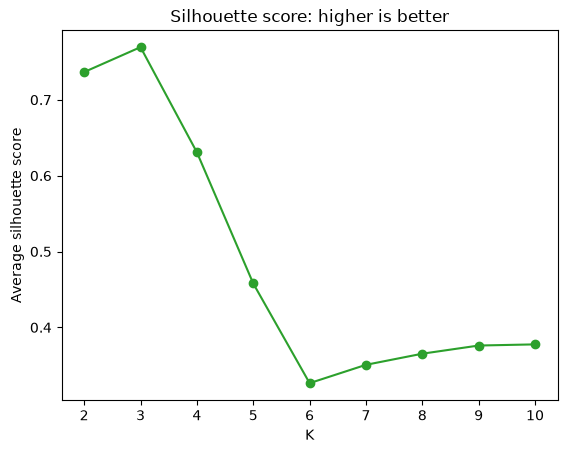

Best K by silhouette: 3


In [21]:
from sklearn.metrics import silhouette_score

ks = range(2, 11)
sil = [silhouette_score(X_blobs, KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_blobs))
       for k in ks]

plt.plot(ks, sil, marker="o", color="tab:green")
plt.xlabel("K")
plt.ylabel("Average silhouette score")
plt.title("Silhouette score: higher is better")
plt.show()
print("Best K by silhouette:", list(ks)[int(np.argmax(sil))])

## Scaling matters

K-Means uses **distance**, so a feature measured in large units dominates. Imagine customers described by *annual income* (£10,000s) and *age* (10s): without scaling, clusters would be based almost entirely on income.

> **Always scale** (e.g. `StandardScaler`) before K-Means, unless all features already use the same units.

## A real example: iris flowers

150 iris flowers with 4 measurements each. We'll **pretend we don't know the species**, cluster the measurements, and only afterwards check whether the clusters match the real species.

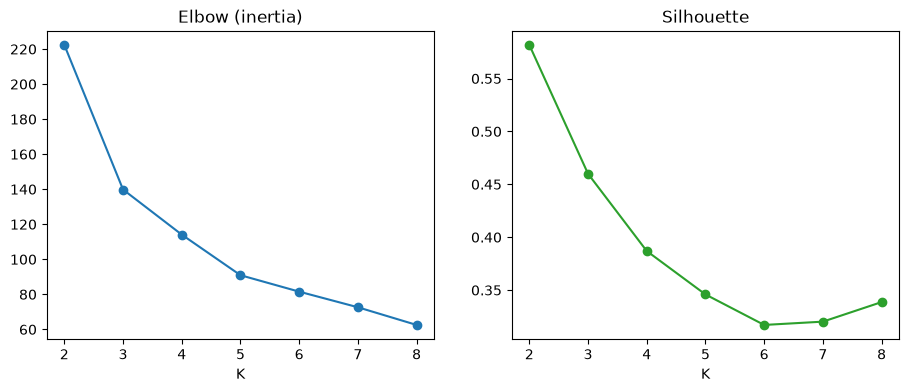

In [22]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris(as_frame=True)
X_iris = iris.data
species = iris.target.map(dict(enumerate(iris.target_names)))

X_iris_scaled = StandardScaler().fit_transform(X_iris)

# Choose K with the elbow and silhouette methods
ks = range(2, 9)
fits = {k: KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_iris_scaled) for k in ks}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), [fits[k].inertia_ for k in ks], marker="o")
axes[0].set_title("Elbow (inertia)")
axes[0].set_xlabel("K")
axes[1].plot(list(ks), [silhouette_score(X_iris_scaled, fits[k].labels_) for k in ks], marker="o", color="tab:green")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("K")
plt.show()

Real data is less clear-cut than the blobs. The **elbow** points to **K = 3** (inertia drops sharply up to 3, then flattens), but the **silhouette** peaks at **K = 2**: one species is very distinct, and the other two overlap. **Choosing K is a judgement call**, and domain knowledge counts: a botanist would say 3. Let's use K = 3.

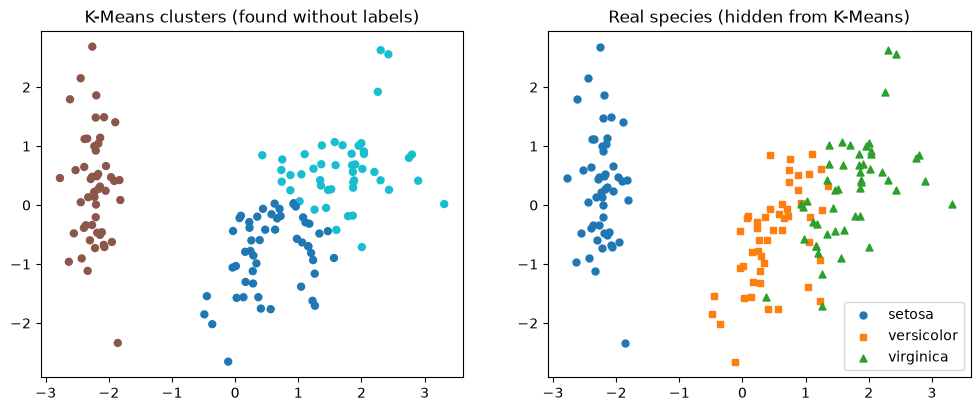

real species,setosa,versicolor,virginica
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


In [23]:
km_iris = fits[3]
clusters = km_iris.labels_

# PCA squeezes the 4 features into 2 so we can plot them (for display only)
X_2d = PCA(n_components=2).fit_transform(X_iris_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="tab10", s=25)
axes[0].set_title("K-Means clusters (found without labels)")
for name, marker in zip(iris.target_names, ["o", "s", "^"]):
    mask = species == name
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], marker=marker, s=25, label=name)
axes[1].set_title("Real species (hidden from K-Means)")
axes[1].legend()
plt.show()

pd.crosstab(pd.Series(clusters, name="cluster"), species.rename("real species"))

**Without ever seeing the labels**, K-Means separates *setosa* perfectly and mostly separates *versicolor* from *virginica*, which really do overlap in their measurements. Cluster numbers are arbitrary (cluster 0 isn't "species 0"); what matters is which points end up together.

### Describing the clusters

In a business setting, the final step is to **profile** each cluster, for example *"cluster 2 = young, high-spending customers"*:

In [24]:
X_iris.assign(cluster=clusters).groupby("cluster").mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97


## K-Means: strengths and limitations

| ✅ Strengths | ⚠️ Limitations |
|---|---|
| Simple, fast, scales to large data | You must choose K |
| Easy to explain | Assumes round, similar-sized clusters |
| Centroids are easy to interpret | Sensitive to scaling and outliers |
| | Random starts can give different results (use `n_init`) |
| | Only works with numeric features |

For odd-shaped clusters or noise, look at **DBSCAN**; for nested groups, **hierarchical clustering**.

---
# Summary

| Topic | Key idea |
|---|---|
| **GridSearchCV** | Tries every combination; thorough but the cost multiplies |
| **RandomizedSearchCV** | Tries `n_iter` random combinations; explores wide spaces cheaply |
| **Tuning rules** | Choose the right `scoring`, use CV on the training data only, tune pipelines, use `loguniform` for scale-type hyperparameters |
| **ROC curve** | TPR vs FPR as the threshold slides from high to low |
| **AUC** | P(random positive scores above random negative); 0.5 = random, 1 = perfect; threshold-free and not fooled by imbalance |
| **K-Means** | Assign each point to its nearest centroid → move centroids to the mean → repeat |
| **Choosing K** | Elbow (inertia) + silhouette (peak) + domain knowledge |
| **Scaling** | Essential for K-Means (and SVM, KNN, logistic regression) |

## Try it yourself

1. Add `"criterion": ["gini", "entropy"]` to the grid. How many fits does it need now? Does the score change?
2. Run `RandomizedSearchCV` with `n_iter=5` and with `n_iter=60`. How do the time and best score change?
3. In the 10-patient example, change patient C's score to 0.50. What happens to the AUC, and why?
4. Run the hand-written K-Means with a different `default_rng` seed. Does it always find the same clusters?
5. Cluster the breast-cancer data with K = 2 (scaled). How well do the clusters match malignant vs benign?